# Segmentación de municipios del Estado de México con KMeans

**Materia:** Extracción de Conocimiento en Bases de Datos  
**Fuente principal:** INEGI — Censo de Población y Vivienda 2020 (ITER)  
**Validación externa:** CONAPO — Índices de Marginación 2020

**Pregunta guía:** ¿Qué municipios del Estado de México presentan características similares en sus condiciones de vivienda, acceso a servicios y conectividad?

## Parte 1 — Imports y configuración

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeClassifier

pd.set_option("display.max_columns", 50)
SEED = 42

BASE = Path.cwd().parent
RAW = BASE / "data" / "raw" / "iter_00_cpv2020" / "conjunto_de_datos" / "conjunto_de_datos_iter_00CSV20.csv"
OUT = BASE / "data" / "processed" / "dataset_limpio.csv"

## Parte 2 — Carga del dataset original

El archivo crudo nacional (`iter_00_cpv2020_csv.zip`, ~35 MB) no se incluye en el repositorio. Debe descargarse desde:
https://www.inegi.org.mx/contenidos/programas/ccpv/2020/datosabiertos/iter/iter_00_cpv2020_csv.zip

y extraerse en `data/raw/`. El CSV usa codificación UTF-8 con BOM (`utf-8-sig`).

In [2]:
df_raw = pd.read_csv(RAW, dtype=str, encoding="utf-8-sig")
print("Filas totales nacionales:", len(df_raw))
print("Columnas:", df_raw.shape[1])
df_raw.head(3)

Filas totales nacionales: 195662
Columnas: 286


,ENTIDAD,NOM_ENT,MUN,NOM_MUN,LOC,NOM_LOC,LONGITUD,LATITUD,ALTITUD,POBTOT,POBFEM,POBMAS,P_0A2,P_0A2_F,P_0A2_M,P_3YMAS,P_3YMAS_F,P_3YMAS_M,P_5YMAS,P_5YMAS_F,P_5YMAS_M,P_12YMAS,P_12YMAS_F,P_12YMAS_M,P_15YMAS,...,VPH_C_SERV,VPH_NDEAED,VPH_DSADMA,VPH_NDACMM,VPH_SNBIEN,VPH_REFRI,VPH_LAVAD,VPH_HMICRO,VPH_AUTOM,VPH_MOTO,VPH_BICI,VPH_RADIO,VPH_TV,VPH_PC,VPH_TELEF,VPH_CEL,VPH_INTER,VPH_STVP,VPH_SPMVPI,VPH_CVJ,VPH_SINRTV,VPH_SINLTC,VPH_SINCINT,VPH_SINTIC,TAMLOC
0,00,Total nacional,000,Total nacional,0000,Total nacional,NaN,NaN,NaN,126014024,64540634,61473390,5764054,2848875,2915179,119976584,61554567,58422017,115693273,59433559,56259714,100528155,51962264,48565891,93985354,...,32671764,79584,32979844,16874580,581095,30811260,25610544,16651199,16340788,4227460,7469168,23772973,32031555,13204680,13184550,30775898,18307193,15211306,6616141,4047100,1788552,3170894,15108204,852871,*
1,00,Total nacional,000,Total nacional,9998,Localidades de una vivienda,NaN,NaN,NaN,250354,96869,153485,10493,5193,5300,239441,91463,147978,232086,87931,144155,207748,76111,131637,197411,...,35091,4842,43668,24373,5136,38199,26412,13608,30940,15001,13600,36738,40001,5797,3523,47005,8385,18981,1732,1113,12775,14143,51293,7154,*
2,00,Total nacional,000,Total nacional,9999,Localidades de dos viviendas,NaN,NaN,NaN,147125,61324,85801,6798,3407,3391,139757,57628,82129,135028,55256,79772,119223,47543,71680,111530,...,19807,2935,23841,16122,4115,21775,15880,7902,16699,8076,6330,20009,23198,3588,2177,25581,5027,11306,971,708,8247,10065,29741,5283,*


## Parte 3 — Revisión inicial de la estructura

Cada fila es una localidad. Los totales municipales son los registros con `LOC == "0000"`.

In [3]:
df_raw["NOM_LOC"].value_counts().head(8)

NOM_LOC
Total del Municipio             2469
Localidades de una vivienda     1990
Localidades de dos viviendas    1738
San Antonio                      647
Ninguno                          586
San José                         546
La Esperanza                     541
San Isidro                       536
Name: count, dtype: int64

## Parte 4 — Filtro: municipios del Estado de México

- `LOC == "0000"`: registro municipal.
- `ENTIDAD == "15"`: Estado de México.
- Se excluye la fila `MUN == "000"` (total de la entidad).

Se esperan exactamente **125 municipios**.

In [4]:
mun = df_raw[
    (df_raw["LOC"] == "0000")
    & (df_raw["ENTIDAD"] == "15")
    & (df_raw["MUN"] != "000")
].copy()
assert len(mun) == 125, f"Se esperaban 125 municipios, hay {len(mun)}"
mun[["MUN", "NOM_MUN", "POBTOT"]].head()

,MUN,NOM_MUN,POBTOT
90524,001,Acambay de Ruíz Castañeda,67872
90628,002,Acolman,171507
90661,003,Aculco,49266
90732,004,Almoloya de Alquisiras,15333
90771,005,Almoloya de Juárez,174587


## Parte 5 — Limpieza de valores especiales y tipos

El ITER usa `*` para valores no disponibles por redondeo o por ley de confidencialidad. Se convierten las columnas seleccionadas a numérico (`errors="coerce"`) y se verifica que no queden valores nulos.

In [5]:
id_cols = ["MUN", "NOM_MUN"]
desc_cols = ["POBTOT", "TVIVHAB", "VIVPAR_HAB", "VIVPARH_CV"]
vph_cols = ["VPH_AGUADV", "VPH_DRENAJ", "VPH_C_ELEC", "VPH_INTER", "VPH_PC", "VPH_CEL", "VPH_AUTOM"]
direct_cols = ["GRAPROES", "PROM_OCUP"]

df = mun[id_cols + desc_cols + vph_cols + direct_cols].copy()

for c in desc_cols + vph_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
for c in direct_cols:
    df[c] = df[c].str.replace(",", ".", regex=False)
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Valores '*' en las columnas seleccionadas:", int((mun[desc_cols + vph_cols + direct_cols] == "*").sum().sum()))
print("Nulos tras conversión:", int(df.isna().sum().sum()))
df.describe().loc[["min", "max"]].round(2)

Valores '*' en las columnas seleccionadas: 0
Nulos tras conversión: 0


,POBTOT,TVIVHAB,VIVPAR_HAB,VIVPARH_CV,VPH_AGUADV,VPH_DRENAJ,VPH_C_ELEC,VPH_INTER,VPH_PC,VPH_CEL,VPH_AUTOM,GRAPROES,PROM_OCUP
min,4862.0,1234.0,1223.0,1216.0,1216.0,1192.0,1215.0,63.0,86.0,897.0,458.0,6.48,3.27
max,1645352.0,448688.0,432424.0,448068.0,443357.0,445737.0,447378.0,290588.0,202160.0,401562.0,186075.0,12.27,4.59


## Parte 6 — Selección de variables

Selección basada en el diccionario oficial (`referencias/fd_iter_cpv2020.pdf`):

| Variable | Significado | Rol |
|---|---|---|
| `VIVPARH_CV` | Viviendas particulares habitadas con características | Denominador |
| `VPH_AGUADV` | Agua entubada en la vivienda | Servicios |
| `VPH_DRENAJ` | Drenaje | Servicios |
| `VPH_C_ELEC` | Energía eléctrica | Servicios |
| `VPH_INTER` | Internet | Conectividad |
| `VPH_PC` | Computadora, laptop o tablet | Conectividad/equipamiento |
| `VPH_CEL` | Teléfono celular | Conectividad |
| `VPH_AUTOM` | Automóvil o camioneta | Equipamiento |
| `GRAPROES` | Grado promedio de escolaridad | Educación (directa) |
| `PROM_OCUP` | Promedio de ocupantes por vivienda | Densidad (directa) |

**Nota metodológica importante:** los conteos `VPH_*` se expresan respecto al universo de viviendas particulares habitadas **con características** (`VIVPARH_CV`), no respecto a `VIVPAR_HAB`. Al validar los datos se comprobó que dividir entre `VIVPAR_HAB` produce proporciones mayores a 1 en varios municipios, porque `VIVPARH_CV` es el universo real de esos indicadores según INEGI. `POBTOT` se conserva solo como variable descriptiva para evitar que el tamaño del municipio domine el clustering.

In [6]:
for c in vph_cols:
    df["p_" + c.replace("VPH_", "").lower()] = df[c] / df["VIVPARH_CV"]

prop_cols = [c for c in df.columns if c.startswith("p_")]
df[prop_cols].describe().loc[["min", "max", "mean"]].round(4)

,p_aguadv,p_drenaj,p_c_elec,p_inter,p_pc,p_cel,p_autom
min,0.7006,0.5777,0.9654,0.0375,0.0381,0.5414,0.2222
max,1.0000,0.9979,0.9994,0.7571,0.6131,0.9444,0.6390
mean,0.9583,0.9410,0.9921,0.3930,0.2820,0.8475,0.4074


## Parte 7 — Proporciones y verificación

Las proporciones deben quedar acotadas en [0, 1].

In [7]:
fuera_de_rango = int(((df[prop_cols] < 0) | (df[prop_cols] > 1)).sum().sum())
assert fuera_de_rango == 0, f"Proporciones fuera de rango: {fuera_de_rango}"
print("Todas las proporciones están en [0, 1]:", fuera_de_rango == 0)
df[["NOM_MUN"] + prop_cols].head()

Todas las proporciones están en [0, 1]: True


,NOM_MUN,p_aguadv,p_drenaj,p_c_elec,p_inter,p_pc,p_cel,p_autom
90524,Acambay de Ruíz Castañeda,0.896036,0.789828,0.973995,0.171049,0.142282,0.770266,0.362350
90628,Acolman,0.903105,0.988473,0.997770,0.499514,0.346840,0.909376,0.404363
90661,Aculco,0.928566,0.802830,0.975143,0.164054,0.119847,0.821721,0.454149
90732,Almoloya de Alquisiras,0.958423,0.896774,0.986858,0.224134,0.167742,0.845639,0.475747
90771,Almoloya de Juárez,0.925519,0.873486,0.987270,0.263293,0.204433,0.801019,0.363779


## Parte 8 — Guardado del dataset procesado

Salida: `data/processed/dataset_limpio.csv` (125 filas, una por municipio). Este archivo sí se sube al repositorio.

In [8]:
df.to_csv(OUT, index=False, encoding="utf-8-sig")
verif = pd.read_csv(OUT)
print("Guardado:", OUT)
print("Filas:", len(verif), "| Columnas:", len(verif.columns))
verif.head()

Guardado: C:\Users\corey\OneDrive\Desktop\Proyecto-Articulo\data\processed\dataset_limpio.csv
Filas: 125 | Columnas: 22


,MUN,NOM_MUN,POBTOT,TVIVHAB,VIVPAR_HAB,VIVPARH_CV,VPH_AGUADV,VPH_DRENAJ,VPH_C_ELEC,VPH_INTER,VPH_PC,VPH_CEL,VPH_AUTOM,GRAPROES,PROM_OCUP,p_aguadv,p_drenaj,p_c_elec,p_inter,p_pc,p_cel,p_autom
0,1,Acambay de Ruíz Castañeda,67872,17393,16912,17381,15574,13728,16929,2973,2473,13388,6298,8.30,3.90,0.896036,0.789828,0.973995,0.171049,0.142282,0.770266,0.362350
1,2,Acolman,171507,45406,41825,45286,40898,44764,45185,22621,15707,41182,18312,9.82,3.65,0.903105,0.988473,0.997770,0.499514,0.346840,0.909376,0.404363
2,3,Aculco,49266,13111,12731,13075,12141,10497,12750,2145,1567,10744,5938,8.02,3.76,0.928566,0.802830,0.975143,0.164054,0.119847,0.821721,0.454149
3,4,Almoloya de Alquisiras,15333,4191,4146,4185,4011,3753,4130,938,702,3539,1991,8.14,3.66,0.958423,0.896774,0.986858,0.224134,0.167742,0.845639,0.475747
4,5,Almoloya de Juárez,174587,42214,40020,42185,39043,36848,41648,11107,8624,33791,15346,8.68,4.03,0.925519,0.873486,0.987270,0.263293,0.204433,0.801019,0.363779


## Parte 9 — Estadística descriptiva del dataset procesado

El análisis exploratorio se realiza a partir de `data/processed/dataset_limpio.csv`, de modo que esta fase depende únicamente del artefacto reproducible y no del archivo crudo nacional.

In [9]:
df = pd.read_csv(OUT)
print("Dimensiones:", df.shape)
print("Nulos totales:", int(df.isna().sum().sum()))
df.describe().round(3)

Dimensiones: (125, 22)
Nulos totales: 0


,MUN,POBTOT,TVIVHAB,VIVPAR_HAB,VIVPARH_CV,VPH_AGUADV,VPH_DRENAJ,VPH_C_ELEC,VPH_INTER,VPH_PC,VPH_CEL,VPH_AUTOM,GRAPROES,PROM_OCUP,p_aguadv,p_drenaj,p_c_elec,p_inter,p_pc,p_cel,p_autom
count,125.000,125.000,125.000,125.000,125.000,125.000,125.000,125.000,125.000,125.000,125.000,125.000,125.000,125.000,125.000,125.000,125.000,125.000,125.000,125.000,125.000
mean,63.000,135939.344,36556.264,34427.592,36491.048,35513.128,35520.664,36346.064,20492.200,14814.832,32395.944,15547.872,9.267,3.901,0.958,0.941,0.992,0.393,0.282,0.847,0.407
std,36.228,237262.089,65721.746,61867.519,65628.593,64933.979,65420.565,65523.426,43599.477,31546.045,59353.364,28973.837,1.184,0.270,0.046,0.077,0.008,0.182,0.136,0.066,0.084
min,1.000,4862.000,1234.000,1223.000,1216.000,1216.000,1192.000,1215.000,63.000,86.000,897.000,458.000,6.480,3.270,0.701,0.578,0.965,0.038,0.038,0.541,0.222
25%,32.000,23675.000,6081.000,5499.000,6069.000,5759.000,5184.000,5925.000,1553.000,974.000,4366.000,2073.000,8.490,3.730,0.940,0.917,0.990,0.240,0.173,0.816,0.357
50%,63.000,46757.000,11583.000,11468.000,11556.000,10860.000,10497.000,11530.000,3283.000,2473.000,9582.000,4469.000,9.350,3.890,0.974,0.978,0.995,0.403,0.275,0.856,0.402
75%,94.000,108196.000,27121.000,26478.000,27032.000,25517.000,24514.000,26949.000,10746.000,7773.000,23148.000,11361.000,10.090,4.040,0.988,0.991,0.997,0.531,0.367,0.896,0.465
max,125.000,1645352.000,448688.000,432424.000,448068.000,443357.000,445737.000,447378.000,290588.000,202160.000,401562.000,186075.000,12.270,4.590,1.000,0.998,0.999,0.757,0.613,0.944,0.639


**Lectura del equipo:** *(redactar aquí las observaciones sobre rangos, medias y valores extremos).*

## Parte 10 — Distribuciones de las variables de segmentación

Se grafican las 7 proporciones de vivienda/conectividad más el grado promedio de escolaridad. La línea punteada marca la media estatal.

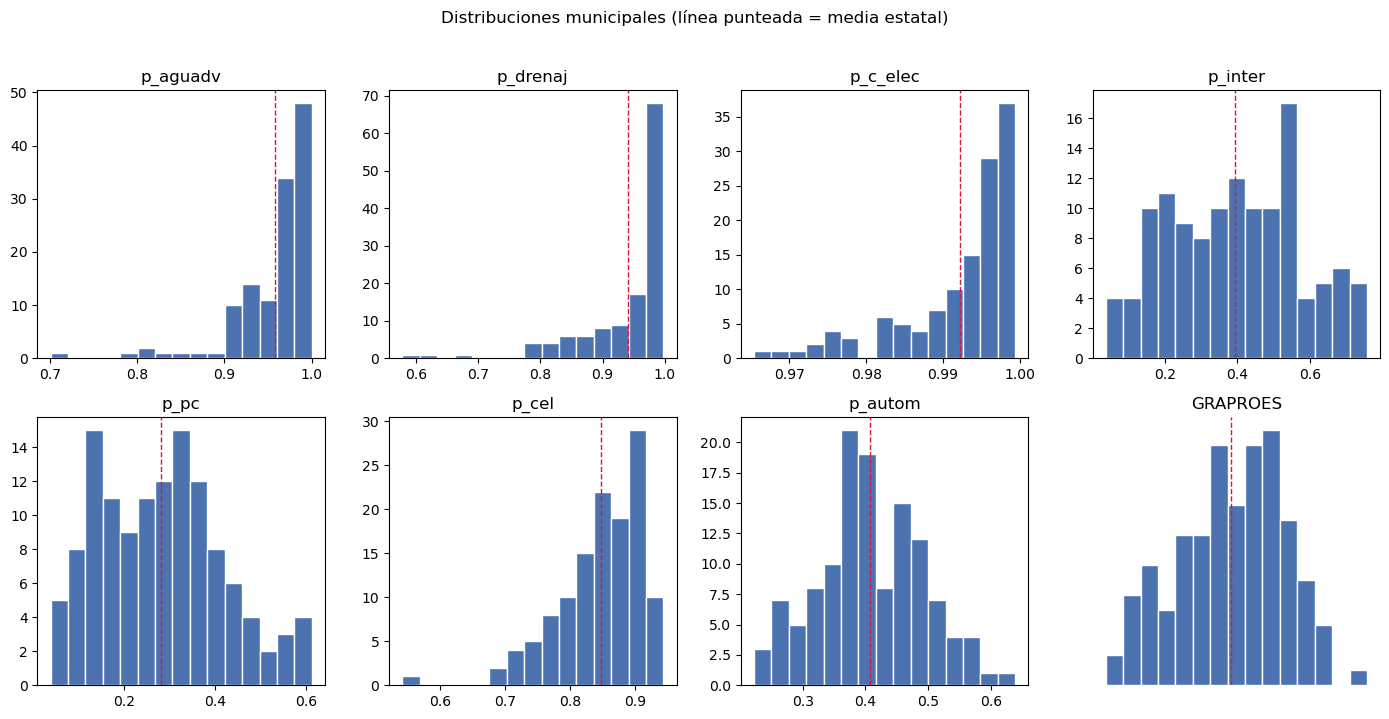

In [10]:
prop_cols = ["p_aguadv", "p_drenaj", "p_c_elec", "p_inter", "p_pc", "p_cel", "p_autom"]
IMG = BASE / "imagenes"

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, c in zip(axes.flat, prop_cols + ["GRAPROES"]):
    ax.hist(df[c], bins=15, color="#4C72B0", edgecolor="white")
    ax.axvline(df[c].mean(), color="crimson", linestyle="--", linewidth=1)
    ax.set_title(c)
axes.flat[-1].axis("off")
fig.suptitle("Distribuciones municipales (línea punteada = media estatal)", y=1.02)
fig.tight_layout()
fig.savefig(IMG / "grafica_1.png", dpi=150, bbox_inches="tight")
plt.show()

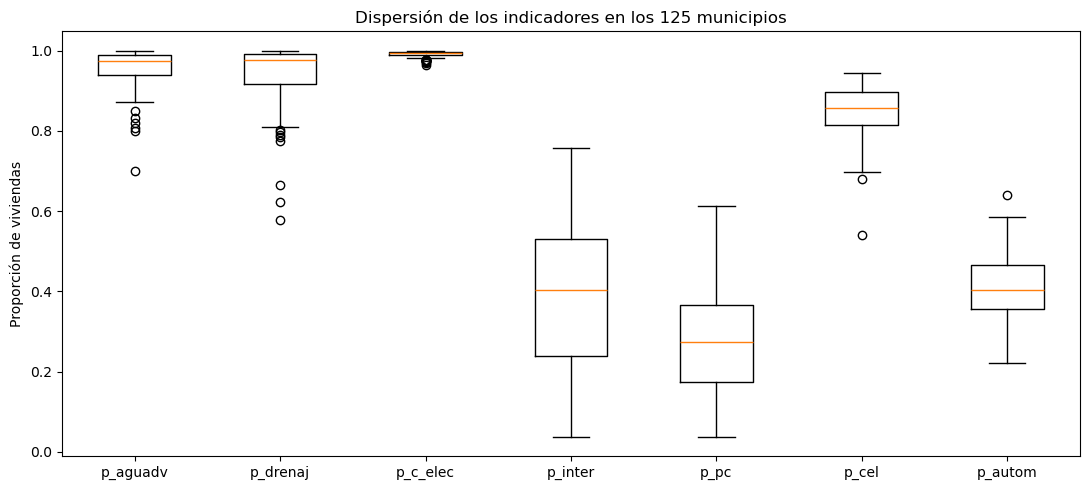

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot([df[c] for c in prop_cols], tick_labels=prop_cols)
ax.set_ylabel("Proporción de viviendas")
ax.set_title("Dispersión de los indicadores en los 125 municipios")
fig.tight_layout()
fig.savefig(IMG / "grafica_2.png", dpi=150, bbox_inches="tight")
plt.show()

**Lectura del equipo:** *(¿qué variables muestran mayor dispersión? ¿cuáles son casi homogéneas? ¿qué sugiere eso para el clustering?)*

## Parte 11 — Municipios extremos en acceso a internet

La conectividad (`p_inter`) es la variable con mayor rango observado. Se contrastan los 10 municipios con mayor y menor acceso.

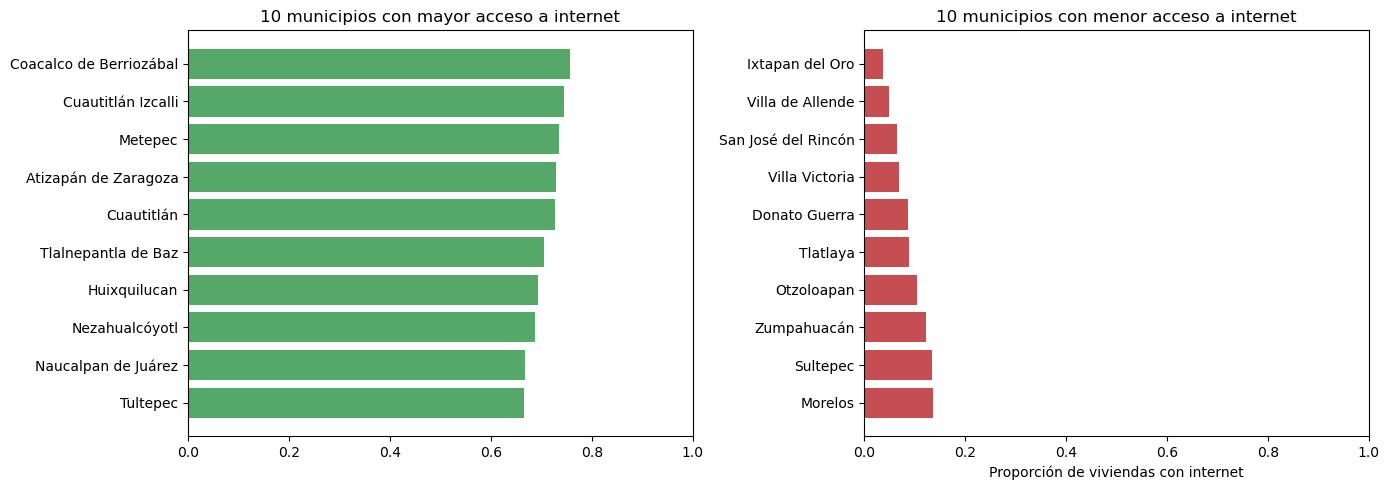

                NOM_MUN  p_inter
Coacalco de Berriozábal 0.757070
     Cuautitlán Izcalli 0.745537
                Metepec 0.734380
   Atizapán de Zaragoza 0.729567
             Cuautitlán 0.728117
    Tlalnepantla de Baz 0.705680
           Huixquilucan 0.693844
         Nezahualcóyotl 0.687356
    Naucalpan de Juárez 0.667722
               Tultepec 0.666432

            NOM_MUN  p_inter
            Morelos 0.135566
           Sultepec 0.135061
        Zumpahuacán 0.121844
         Otzoloapan 0.103557
           Tlatlaya 0.089357
      Donato Guerra 0.085674
     Villa Victoria 0.069330
San José del Rincón 0.064985
   Villa de Allende 0.048880
    Ixtapan del Oro 0.037522


In [12]:
orden = df.sort_values("p_inter", ascending=False)
top = orden.head(10).iloc[::-1]
bottom = orden.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
axes[0].barh(top["NOM_MUN"], top["p_inter"], color="#55A868")
axes[0].set_title("10 municipios con mayor acceso a internet")
axes[1].barh(bottom["NOM_MUN"], bottom["p_inter"], color="#C44E52")
axes[1].set_title("10 municipios con menor acceso a internet")
axes[1].set_xlabel("Proporción de viviendas con internet")
for ax in axes:
    ax.set_xlim(0, 1)
fig.tight_layout()
fig.savefig(IMG / "grafica_3.png", dpi=150, bbox_inches="tight")
plt.show()

print(top[["NOM_MUN", "p_inter"]].iloc[::-1].to_string(index=False))
print()
print(bottom[["NOM_MUN", "p_inter"]].to_string(index=False))

**Lectura del equipo:** *(¿los municipios con menos internet también presentan baja escolaridad o menos servicios? ¿se reconocen regiones específicas del estado?)*

## Parte 12 — Escolaridad y conectividad

Relación entre el grado promedio de escolaridad y el acceso a internet municipal.

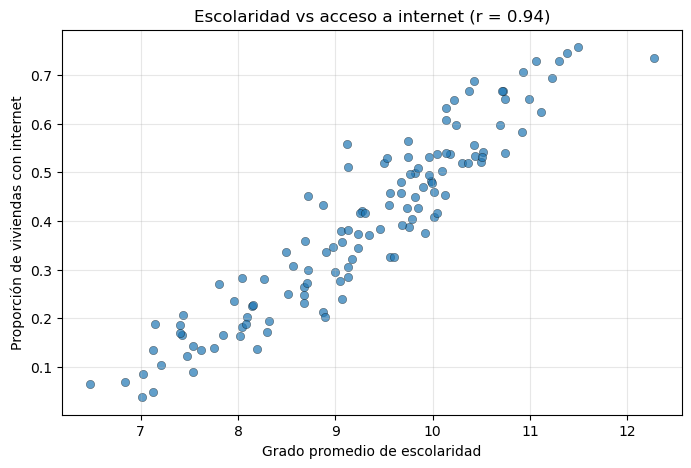

Correlación de Pearson: 0.937


In [13]:
r = df["GRAPROES"].corr(df["p_inter"])
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["GRAPROES"], df["p_inter"], alpha=0.7, edgecolor="black", linewidth=0.3)
ax.set_xlabel("Grado promedio de escolaridad")
ax.set_ylabel("Proporción de viviendas con internet")
ax.set_title(f"Escolaridad vs acceso a internet (r = {r:.2f})")
ax.grid(alpha=0.3)
fig.savefig(IMG / "grafica_4.png", dpi=150, bbox_inches="tight")
plt.show()
print("Correlación de Pearson:", round(r, 3))

## Parte 13 — Correlaciones entre variables de segmentación

Matriz de correlaciones de las 9 variables candidatas al KMeans. Sirve para detectar redundancias antes del modelado.

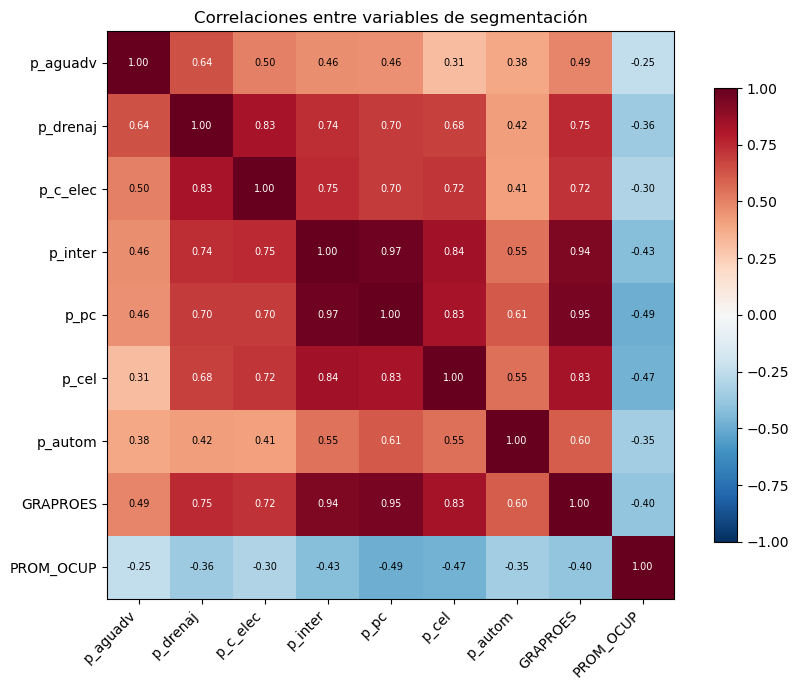

Pares más correlacionados:
p_inter   p_pc        0.972764
p_pc      p_inter     0.972764
          GRAPROES    0.949449
GRAPROES  p_pc        0.949449

p_cel      PROM_OCUP   -0.474651
PROM_OCUP  p_cel       -0.474651
           p_pc        -0.486792
p_pc       PROM_OCUP   -0.486792


In [14]:
corr_vars = prop_cols + ["GRAPROES", "PROM_OCUP"]
corr = df[corr_vars].corr()
n = len(corr_vars)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(n), corr_vars, rotation=45, ha="right")
ax.set_yticks(range(n), corr_vars)
for i in range(n):
    for j in range(n):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(v) > 0.55 else "black")
fig.colorbar(im, shrink=0.8)
ax.set_title("Correlaciones entre variables de segmentación")
fig.tight_layout()
fig.savefig(IMG / "grafica_5.png", dpi=150, bbox_inches="tight")
plt.show()

sin_diag = corr.where(~np.eye(n, dtype=bool)).stack().sort_values(ascending=False)
print("Pares más correlacionados:")
print(sin_diag.head(4).to_string())
print()
print(sin_diag.tail(4).to_string())

**Lectura del equipo:** *(¿hay variables tan correlacionadas que convenga quitar antes del KMeans? ¿`p_inter` y `p_pc` aportan información distinta?)*

## Parte 14 — Variables finales y estandarización

**Decisión del equipo:** se elimina `p_pc` de las variables de clustering porque su correlación con `p_inter` es r = 0.97 (miden prácticamente la misma dimensión y la sobre-representarían en el cálculo de distancias). Se conservan **8 variables**. `GRAPROES` y `p_inter` mantienen correlación alta (r = 0.94) pero miden conceptos distintos (educación vs conectividad), por lo que se conservan ambas.

Antes de KMeans todas las variables se estandarizan con `StandardScaler`, porque están en escalas distintas (proporciones 0–1, escolaridad en años, ocupantes por vivienda).

In [15]:
clust_vars = ["p_aguadv", "p_drenaj", "p_c_elec", "p_inter", "p_cel", "p_autom", "GRAPROES", "PROM_OCUP"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[clust_vars])
pd.DataFrame(X_scaled, columns=clust_vars).describe().loc[["mean", "std"]].round(3)

,p_aguadv,p_drenaj,p_c_elec,p_inter,p_cel,p_autom,GRAPROES,PROM_OCUP
mean,-0.000,-0.000,0.000,0.000,-0.000,-0.000,-0.000,0.000
std,1.004,1.004,1.004,1.004,1.004,1.004,1.004,1.004


## Parte 15 — Elección del número de clusters (k)

Se evalúan dos criterios para k entre 2 y 10:

- **Método del codo** (inercia): busca el punto donde agregar clusters deja de reducir mucho la dispersión interna.
- **Coeficiente de silueta**: mide qué tan bien cada municipio queda dentro de su cluster frente a los vecinos más cercanos (entre −1 y 1; más alto es mejor).

 k  inercia  silueta
 2 578.6087   0.3871
 3 464.7349   0.2694
 4 392.6111   0.2350
 5 349.2229   0.2281
 6 317.8792   0.2208
 7 282.3003   0.2336
 8 250.8987   0.2263
 9 234.0231   0.2283
10 211.9296   0.2362


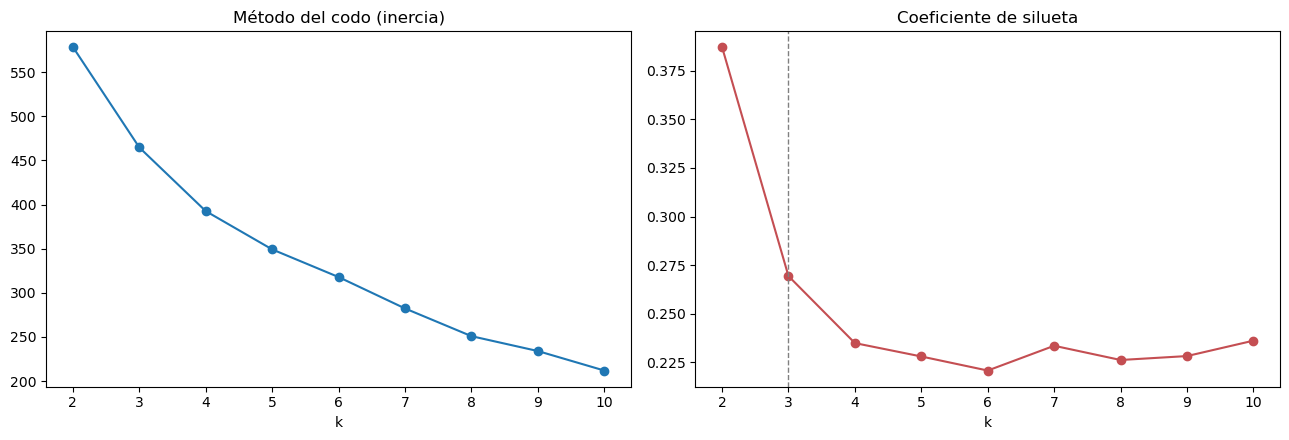

In [16]:
resultados_k = []
for k in range(2, 11):
    km_tmp = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X_scaled)
    resultados_k.append({"k": k, "inercia": km_tmp.inertia_,
                         "silueta": silhouette_score(X_scaled, km_tmp.labels_)})
tabla_k = pd.DataFrame(resultados_k)
print(tabla_k.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(tabla_k["k"], tabla_k["inercia"], marker="o")
axes[0].set_title("Método del codo (inercia)")
axes[0].set_xlabel("k")
axes[1].plot(tabla_k["k"], tabla_k["silueta"], marker="o", color="#C44E52")
axes[1].axvline(3, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Coeficiente de silueta")
axes[1].set_xlabel("k")
fig.tight_layout()
fig.savefig(IMG / "grafica_6.png", dpi=150, bbox_inches="tight")
plt.show()

**Justificación de la elección:** la silueta maximiza en k = 2 (0.39), pero produce una división casi binaria urbano/rural que mezcla un estrato intermedio amplio. El equipo eligió **k = 3** porque mantiene cohesión aceptable (silueta ≈ 0.27), el codo se flexiona entre k = 3 y k = 4, y los tres grupos resultantes son interpretables y útiles para contrastarse después con los grados de marginación de CONAPO. La preferencia de la métrica por k = 2 se documenta como parte de la decisión.

## Parte 16 — Entrenamiento del modelo final

KMeans con `random_state` fijo (`SEED = 42`) y `n_init = 10` para garantizar reproducibilidad. Las etiquetas numéricas de los clusters son arbitrarias; se renombran según el nivel promedio de conectividad (`p_inter`) en niveles **bajo / intermedio / alto**, sin que ello implique categorías oficiales.

In [17]:
k_final = 3
km = KMeans(n_clusters=k_final, n_init=10, random_state=SEED)
df["cluster"] = km.fit_predict(X_scaled)

orden = df.groupby("cluster")["p_inter"].mean().sort_values().index
nombres = dict(zip(orden, ["bajo", "intermedio", "alto"]))
df["perfil"] = df["cluster"].map(nombres)

print("Silueta del modelo final:", round(silhouette_score(X_scaled, km.labels_), 4))
print(df["perfil"].value_counts().reindex(["bajo", "intermedio", "alto"]))

Silueta del modelo final: 0.2694
perfil
bajo          16
intermedio    50
alto          59
Name: count, dtype: int64


## Parte 17 — Perfiles promedio de los clusters

Promedios en unidades originales por grupo, y mapa de calor de los perfiles estandarizados (desviaciones respecto a la media estatal) para visualizar qué caracteriza a cada cluster.

            municipios  p_aguadv  p_drenaj  p_c_elec  p_inter  p_cel  p_autom  GRAPROES  PROM_OCUP
perfil                                                                                            
bajo                16     0.898     0.790     0.977    0.128  0.736    0.313     7.425      4.082
intermedio          50     0.954     0.932     0.991    0.299  0.826    0.389     8.731      3.962
alto                59     0.978     0.989     0.997    0.544  0.896    0.449    10.220      3.800


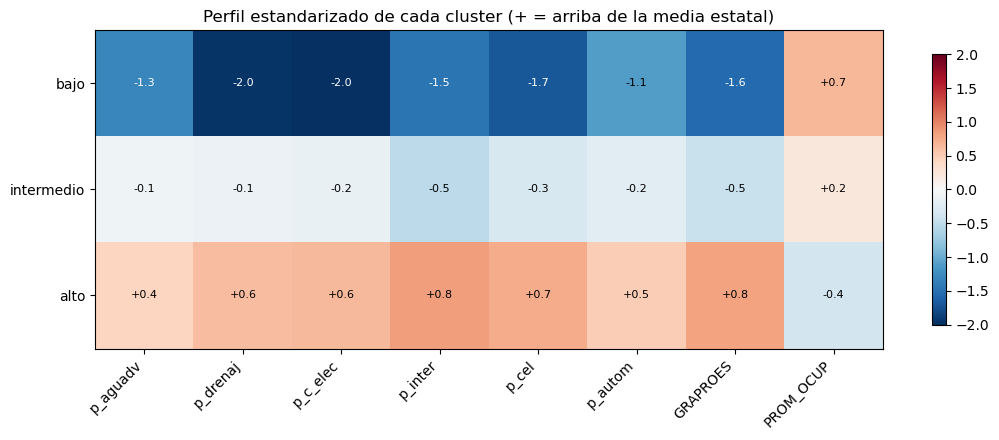

      alto: Ecatepec de Morelos, Nezahualcóyotl, Toluca, Naucalpan de Juárez
intermedio: Chimalhuacán, Almoloya de Juárez, Ixtlahuaca, Atlacomulco
      bajo: San Felipe del Progreso, Villa Victoria, San José del Rincón, Acambay de Ruíz Castañeda


In [18]:
perf = df.groupby("perfil")[clust_vars].mean().reindex(["bajo", "intermedio", "alto"]).round(3)
perf_n = df.groupby("perfil").size().reindex(["bajo", "intermedio", "alto"])
perf.insert(0, "municipios", perf_n)
print(perf.to_string())

z = (perf[clust_vars] - df[clust_vars].mean()) / df[clust_vars].std()
fig, ax = plt.subplots(figsize=(11, 4.5))
im = ax.imshow(z, cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(len(clust_vars)), clust_vars, rotation=45, ha="right")
ax.set_yticks(range(len(z)), z.index)
for i in range(len(z)):
    for j in range(len(clust_vars)):
        ax.text(j, i, f"{z.iloc[i, j]:+.1f}", ha="center", va="center", fontsize=8,
                color="white" if abs(z.iloc[i, j]) > 1.2 else "black")
fig.colorbar(im, shrink=0.85)
ax.set_title("Perfil estandarizado de cada cluster (+ = arriba de la media estatal)")
fig.tight_layout()
fig.savefig(IMG / "grafica_7.png", dpi=150, bbox_inches="tight")
plt.show()

for p in ["alto", "intermedio", "bajo"]:
    ej = df[df["perfil"] == p].nlargest(4, "POBTOT")["NOM_MUN"].tolist()
    print(f'{p:>10}:', ', '.join(ej))

**Lectura del equipo:** *(describir cada perfil con sus palabras y comentar casos llamativos, p. ej. Chimalhuacán).*

## Parte 18 — Exportación de resultados

- `outputs/resultados_modelo.csv`: municipio + cluster asignado + variables usadas.
- `outputs/resumen_resultados.csv`: perfil promedio por cluster.

In [19]:
res = df[["MUN", "NOM_MUN", "POBTOT", "cluster", "perfil"] + clust_vars]
res.to_csv(BASE / "outputs" / "resultados_modelo.csv", index=False, encoding="utf-8-sig")

resumen = df.groupby("perfil")[clust_vars].mean().round(4).reindex(["bajo", "intermedio", "alto"])
resumen.insert(0, "municipios", df.groupby("perfil").size().reindex(["bajo", "intermedio", "alto"]))
resumen.to_csv(BASE / "outputs" / "resumen_resultados.csv", encoding="utf-8-sig")

print("Archivos generados en outputs/:")
for f in sorted((BASE / "outputs").glob("*.csv")):
    print(" -", f.name)

Archivos generados en outputs/:
 - resultados_modelo.csv
 - resumen_resultados.csv


**Lectura del equipo:** *(síntesis de los resultados del modelo en 3–4 líneas para el artículo).*